# Random Forests
In this notebook, we will see how we can use an *ensemble* of models to generate predictions based on information from a collection of individual models. We will explore this idea with random forests - a collection of decision trees used in a regression task.

**Learning Objectives**

By the end of this notebook, you should be able to:
1. Assess overfitting in a single decision tree regressor model
2. Implement a Majority Vote regressor to leverage results from multiple models
3. Use `scikit-learn`'s classes to implement random forests

**Import modules**

Begin by importing the modules to be used in this notebook

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, VotingRegressor, BaggingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

## A Sea Otter Regression Problem

In this notebook, we will explore data from Aleah Corbo, an MLML student examining the combined effect of environmental features such as tides, weather, and kelp/eelgrass canopy cover on sea otter raft size in Monterey Bay and Elkhorn Slough.

<img src="../images/elkhorn_otter_raft.jpeg" alt="Image of an otter raft" width="500">

The above image is from the California Department of Fish and Wildlife page for Elkhorn Slough, available [HERE](https://wildlife.ca.gov/Conservation/Marine/MPAs/Elkhorn-Slough/lc/576288/lcv/s/Sea%20otters%20in%20Elkhorn%20Slough%20SMR).

Let's read in Aleah's data set for this example into a data frame:

In [2]:
df = pd.read_csv('../data/mock_otter_weekly_data.csv')

In [3]:
df.head()

,Location,Site,Week,Season,Tide,Weather,CanopyCover,OtterCount
0,Monterey Bay,3,1,Winter,Low,Windy,0.697153,7
1,Monterey Bay,3,2,Winter,Mid,Sunny,0.751577,14
2,Monterey Bay,2,3,Winter,Mid,Sunny,0.341262,19
3,Monterey Bay,3,4,Winter,Mid,Cloudy,0.488639,20
4,Monterey Bay,1,5,Winter,High,Sunny,0.427351,21


As we can see, this data set contains several features as well as a predictor variable for the count of otters in an observed raft.

As in our previous classification notebooks, let's encode the text-based data with numerical values:

In [4]:
df['Location Index']=0
df.loc[df['Location']=='Elkhorn Slough', "Location Index"] = 1

In [5]:
df['Season Index']=0
df.loc[df['Season']=='Spring', "Season Index"] = 1
df.loc[df['Season']=='Summer', "Season Index"] = 2
df.loc[df['Season']=='Fall', "Season Index"] = 3

In [6]:
df['Tide Index']=0
df.loc[df['Tide']=='High', "Tide Index"] = 1

In [7]:
df['Weather Index']=0
df.loc[df['Weather']=='Windy', "Weather Index"] = 1
df.loc[df['Weather']=='Sunny', "Weather Index"] = 2
df.loc[df['Weather']=='Cloudy', "Weather Index"] = 3

It's always good to check your work. Let's make sure these were added to the data frame as expected:

In [8]:
df.head()

,Location,Site,Week,Season,Tide,Weather,CanopyCover,OtterCount,Location Index,Season Index,Tide Index,Weather Index
0,Monterey Bay,3,1,Winter,Low,Windy,0.697153,7,0,0,0,1
1,Monterey Bay,3,2,Winter,Mid,Sunny,0.751577,14,0,0,0,2
2,Monterey Bay,2,3,Winter,Mid,Sunny,0.341262,19,0,0,0,2
3,Monterey Bay,3,4,Winter,Mid,Cloudy,0.488639,20,0,0,0,3
4,Monterey Bay,1,5,Winter,High,Sunny,0.427351,21,0,0,1,2


In [9]:
df.tail()

,Location,Site,Week,Season,Tide,Weather,CanopyCover,OtterCount,Location Index,Season Index,Tide Index,Weather Index
99,Elkhorn Slough,2,48,Fall,Low,Sunny,0.597920,35,1,3,0,2
100,Elkhorn Slough,3,49,Fall,Low,Cloudy,0.090215,16,1,3,0,3
101,Elkhorn Slough,2,50,Fall,High,Cloudy,0.206101,7,1,3,1,3
102,Elkhorn Slough,3,51,Fall,High,Windy,0.419623,12,1,3,1,1
103,Elkhorn Slough,2,52,Fall,High,Cloudy,0.367712,14,1,3,1,3


Looks good! Let's have a look at some features in our data relative to the target data:

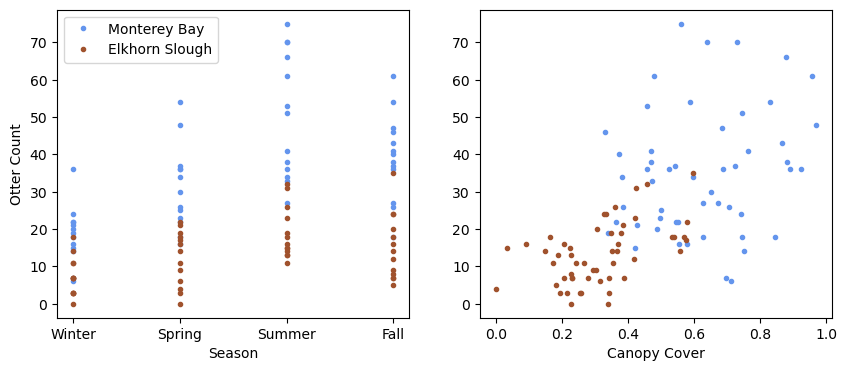

In [10]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(df['Season Index'][df['Location Index']==0],
         df['OtterCount'][df['Location Index']==0],
         '.',label='Monterey Bay', color='cornflowerblue')
plt.plot(df['Season Index'][df['Location Index']==1],
         df['OtterCount'][df['Location Index']==1],
         '.',label='Elkhorn Slough', color='sienna')
plt.ylabel('Otter Count')
plt.xlabel('Season')
plt.xticks([0,1,2,3],['Winter','Spring','Summer','Fall'])
plt.legend(loc=2)

plt.subplot(1,2,2)
plt.plot(df['CanopyCover'][df['Location Index']==0],
         df['OtterCount'][df['Location Index']==0],
         '.',label='Monterey Bay', color='cornflowerblue')
plt.plot(df['CanopyCover'][df['Location Index']==1],
         df['OtterCount'][df['Location Index']==1],
         '.',label='Elkhorn Slough', color='sienna')
plt.xlabel('Canopy Cover')
plt.show()

As we can see, there is a lot of variability in this data set - let's see how well we can predict sea otter raft counts with this data.

## Implementing a Decision Tree Regressor

In our previous notebooks on regression (in the [Basics](https://profmikewood.github.io/machine_learning_book/linear-regression/) section of the notes), we used linear regression. As the name implies, this type of regression assumes linear relationships between the input features and the target variable. However, that may not always be the case - especially if there are categorical variables in the input features (like weather, or tide).

In this notebook, we'll use a decision tree for regression, similar to our classification example. Decision tree regressors are available in the `scikit-learn` package. As with all `scikit-learn` models, let's start by prepping our design matrix and our target data:

In [11]:
X = np.column_stack([df['Location Index'], df['Season Index'],
                     df['Tide Index'], df['Weather Index'], df['CanopyCover']])
y = df['OtterCount']

Next, let's split our data into a training set and testing set:

In [12]:
# split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=17)

Just like in our classification notebook, we can make a regression model with the built in class and then fit it to our training data:

In [13]:
model = DecisionTreeRegressor(max_depth=10, random_state=25)
model.fit(X_train, y_train);

Let's see how our model is performing on both the training set and the testing set:

In [14]:
y_pred_test = model.predict(X_test)
y_pred_train = model.predict(X_train)

Let's see what these results look like:

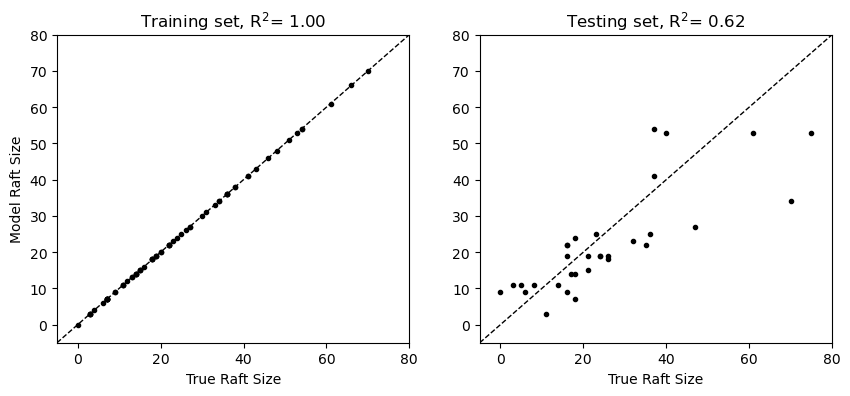

In [15]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(y_train, y_pred_train, 'k.')
plt.plot([-5, 80], [-5, 80],'k--',linewidth=1)
plt.xlim([-5, 80])
plt.ylim([-5, 80])
plt.ylabel('Model Raft Size')
plt.xlabel('True Raft Size')
plt.title(f"Training set, R$^2$= {r2_score(y_train, y_pred_train):.2f}")

plt.subplot(1,2,2)
plt.plot(y_test, y_pred_test, 'k.')
plt.plot([-5, 80], [-5, 80],'k--',linewidth=1)
plt.xlim([-5, 80])
plt.ylim([-5, 80])
plt.xlabel('True Raft Size')
plt.title(f"Testing set, R$^2$= {r2_score(y_test, y_pred_test):.2f}");

In the plot above, we can see that our model has fit the training data perfectly but there is still considerable noise in the training data. This is an example of *overfitting* - the large number of decisions in the model relative to the size of the training data allows it to "memorize" the data points. When models are overfit, they are typically not very good at generalizing to unseen data, which we can see evidence of in our testing set. How can we get around this issue without throwing out too much complexity from our model?

## Majority Voting with Regressors

Another way that we can approach this problem is by considering results from a collection of different regression models. One simple way to approach this regression problem is by *majority vote*. That is, given a set of input features, what is the value assigned to this point by most of the models considered?

For regression, the ensemble prediction $V$ is typically the average (mean) of the individual model predictions $V_i$, i.e.

$$
V =  \frac{1}{N}\sum_{i=1}^N V_i
$$

where $i$ is the index of the models considered. Since this approach uses a collection of different models, it is an example of **ensemble learning**.

In `scikit-learn`, we can fit and implement a majority vote regressor just like any other model. We just need to make a list of our "voters" as follows:

In [16]:
# choose some random example models
voters = [('dt_5_17', DecisionTreeRegressor(max_depth=5, random_state=17)),
          ('dt_10_17',DecisionTreeRegressor(max_depth=10, random_state=17)),
          ('dt_5_41', DecisionTreeRegressor(max_depth=5, random_state=41)),
          ('dt_10_41',DecisionTreeRegressor(max_depth=10, random_state=41))]

# create an ensemble
ensemble = VotingRegressor(voters)

Once we've got our model implemented, we just need to "fit" it like any other model and use it to make predictions:

In [17]:
# fit the ensemble
ensemble.fit(X_train, y_train)

# make some predictions with the ensemble model
y_pred_ensemble_train = ensemble.predict(X_train)
y_pred_ensemble_test = ensemble.predict(X_test)

Let's check out our results:

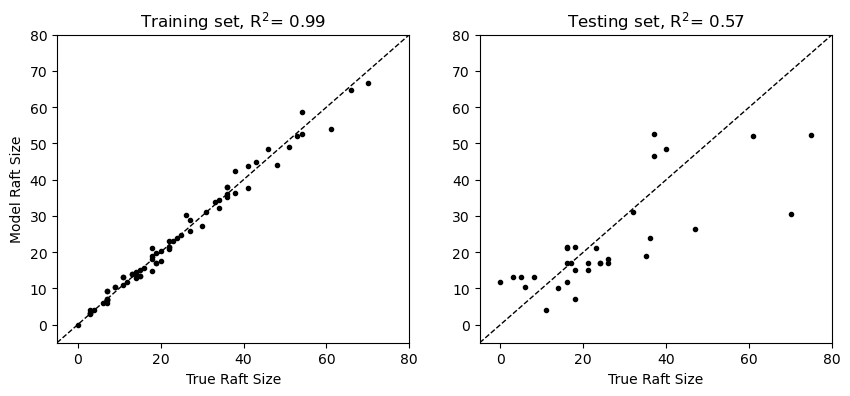

In [18]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(y_train, y_pred_ensemble_train, 'k.')
plt.plot([-5, 80], [-5, 80],'k--',linewidth=1)
plt.xlim([-5, 80])
plt.ylim([-5, 80])
plt.ylabel('Model Raft Size')
plt.xlabel('True Raft Size')
plt.title(f"Training set, R$^2$= {r2_score(y_train, y_pred_ensemble_train):.2f}")

plt.subplot(1,2,2)
plt.plot(y_test, y_pred_ensemble_test, 'k.')
plt.plot([-5, 80], [-5, 80],'k--',linewidth=1)
plt.xlim([-5, 80])
plt.ylim([-5, 80])
plt.xlabel('True Raft Size')
plt.title(f"Testing set, R$^2$= {r2_score(y_test, y_pred_ensemble_test):.2f}");

As we can see in the comparison above, our majority voting regressor has more noise than the previous example because the collection of models is not exactly fit to the data. Let's see how we can improve this model further.

## Bagging
With the majority voting concept in hand, we can consider another approach for reducing variance in our model results - bagging. To motivate the concept of bagging, consider that the decision tree regressor above is built on a very specific training example. The idea of bagging is to use multiple models trained on *different* subsets of data and then *aggregating* the results with majority voting.

The key question to consider is: how do we generate lots of different datasets when we only have a finite amount of training data? The approach used in bagging is *bootstrap sampling* - that is, choosing a random sample (with replacement) from the training data. 

Thus **bagg**ing is the **agg**regation of model results trained on **b**ootstrap samples.

Let's take a look at an example using a decision tree regressor:

In [19]:
bagging = BaggingRegressor(DecisionTreeRegressor(), n_estimators=100,
                                random_state=17)
bagging.fit(X_train, y_train);

As we can see above, this model is created with 100 different decision trees. Let's make some predictions:

In [20]:
y_pred_bagging_train = bagging.predict(X_train)
y_pred_bagging_test = bagging.predict(X_test)

Let's take a look at the results:

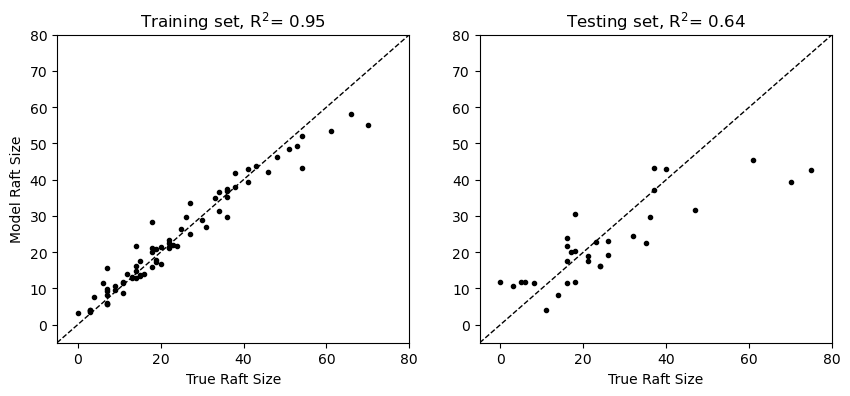

In [21]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(y_train, y_pred_bagging_train, 'k.')
plt.plot([-5, 80], [-5, 80],'k--',linewidth=1)
plt.xlim([-5, 80])
plt.ylim([-5, 80])
plt.ylabel('Model Raft Size')
plt.xlabel('True Raft Size')
plt.title(f"Training set, R$^2$= {r2_score(y_train, y_pred_bagging_train):.2f}")

plt.subplot(1,2,2)
plt.plot(y_test, y_pred_bagging_test, 'k.')
plt.plot([-5, 80], [-5, 80],'k--',linewidth=1)
plt.xlim([-5, 80])
plt.ylim([-5, 80])
plt.xlabel('True Raft Size')
plt.title(f"Testing set, R$^2$= {r2_score(y_test, y_pred_bagging_test):.2f}");

Here, we can see that the aggregate of the decision tree models does not fit the training data as closely - with the upshot that the results with the unseen testing data are improved! This model would be more generalizable to unseen data because the model is not trained on a specific subset of the data.

Since this model is built as a random collection of decision trees, this type of model is often referred to as a "random forest". In addition to bootstrap sampling, random forests also introduce randomness by selecting a random subset of features at each split. Turns out this is also implemented in `scikit-learn`:

In [22]:
rf = RandomForestRegressor(n_estimators=100, max_depth=None, random_state=17)
rf.fit(X_train, y_train);

y_pred_rf_train = rf.predict(X_train)
y_pred_rf_test = rf.predict(X_test)

Let's check out the results:

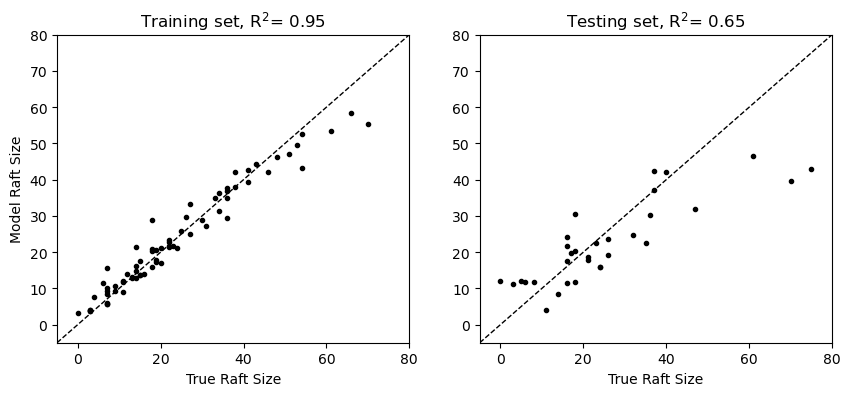

In [23]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(y_train, y_pred_rf_train, 'k.')
plt.plot([-5, 80], [-5, 80],'k--',linewidth=1)
plt.xlim([-5, 80])
plt.ylim([-5, 80])
plt.ylabel('Model Raft Size')
plt.xlabel('True Raft Size')
plt.title(f"Training set, R$^2$= {r2_score(y_train, y_pred_rf_train):.2f}")

plt.subplot(1,2,2)
plt.plot(y_test, y_pred_rf_test, 'k.')
plt.plot([-5, 80], [-5, 80],'k--',linewidth=1)
plt.xlim([-5, 80])
plt.ylim([-5, 80])
plt.xlabel('True Raft Size')
plt.title(f"Testing set, R$^2$= {r2_score(y_test, y_pred_rf_test):.2f}");

**Key Takeaways**

1. A complex model overfit to its training data is not generalizable to unseen data.
2. Bagging is an approach to train a collection of models on different subsets of data and then combine those models using a majority voting approach.
3. A random forest is a collection of decision trees fit on random subsets of data.